5.1 Data Cleaning & Missing Value Strategy

1. Kiểm tra kích thước, cấu trúc & kiểu dữ liệu

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Load master dataset
df = pd.read_csv('../BAINHOM/data/final/master_dataset.csv')

print("Số dòng, số cột:", df.shape)
print("\nThông tin dữ liệu")
print(df.info())

Số dòng, số cột: (10000, 39)

Thông tin dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      10000 non-null  object 
 1   Transaction_Date    10000 non-null  object 
 2   Customer_ID         10000 non-null  object 
 3   Gender              10000 non-null  object 
 4   Age                 10000 non-null  int64  
 5   City                10000 non-null  object 
 6   Product_ID          10000 non-null  int64  
 7   Product_Name        10000 non-null  object 
 8   Category            10000 non-null  object 
 9   Brand               10000 non-null  object 
 10  Quantity            10000 non-null  int64  
 11  Unit_Price_VND      10000 non-null  int64  
 12  Revenue             10000 non-null  int64  
 13  Source_Currency     10000 non-null  object 
 14  Rating              10000 non-null  int64  
 15  Custom

Đánh giá số lượng và tỷ lệ Missing Values của từng cột.

In [104]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percentage (%)': (df.isna().sum() / len(df)) * 100
}).query('Missing_Count > 0').sort_values(by='Missing_Count', ascending=False)

print("THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES)")
print(missing_summary)

THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES)
                  Missing_Count  Missing_Percentage (%)
avg_rating                 8178                   81.78
reviews_count              8178                   81.78
product_type               8178                   81.78
is_for_sale                8178                   81.78
availability               8178                   81.78
category_2                 8178                   81.78
category_3                 8178                   81.78
manufacturer               8178                   81.78
quantity_sold              1822                   18.22
review_count               1822                   18.22
rating_average             1822                   18.22
current_seller             1822                   18.22
fulfillment_type           1822                   18.22
date_created               1822                   18.22
number_of_images           1822                   18.22
favourite_count            1822                   18.22
has_vide

Trực quan hóa Missing Values bằng thư viện missingno.

<Figure size 1200x600 with 0 Axes>

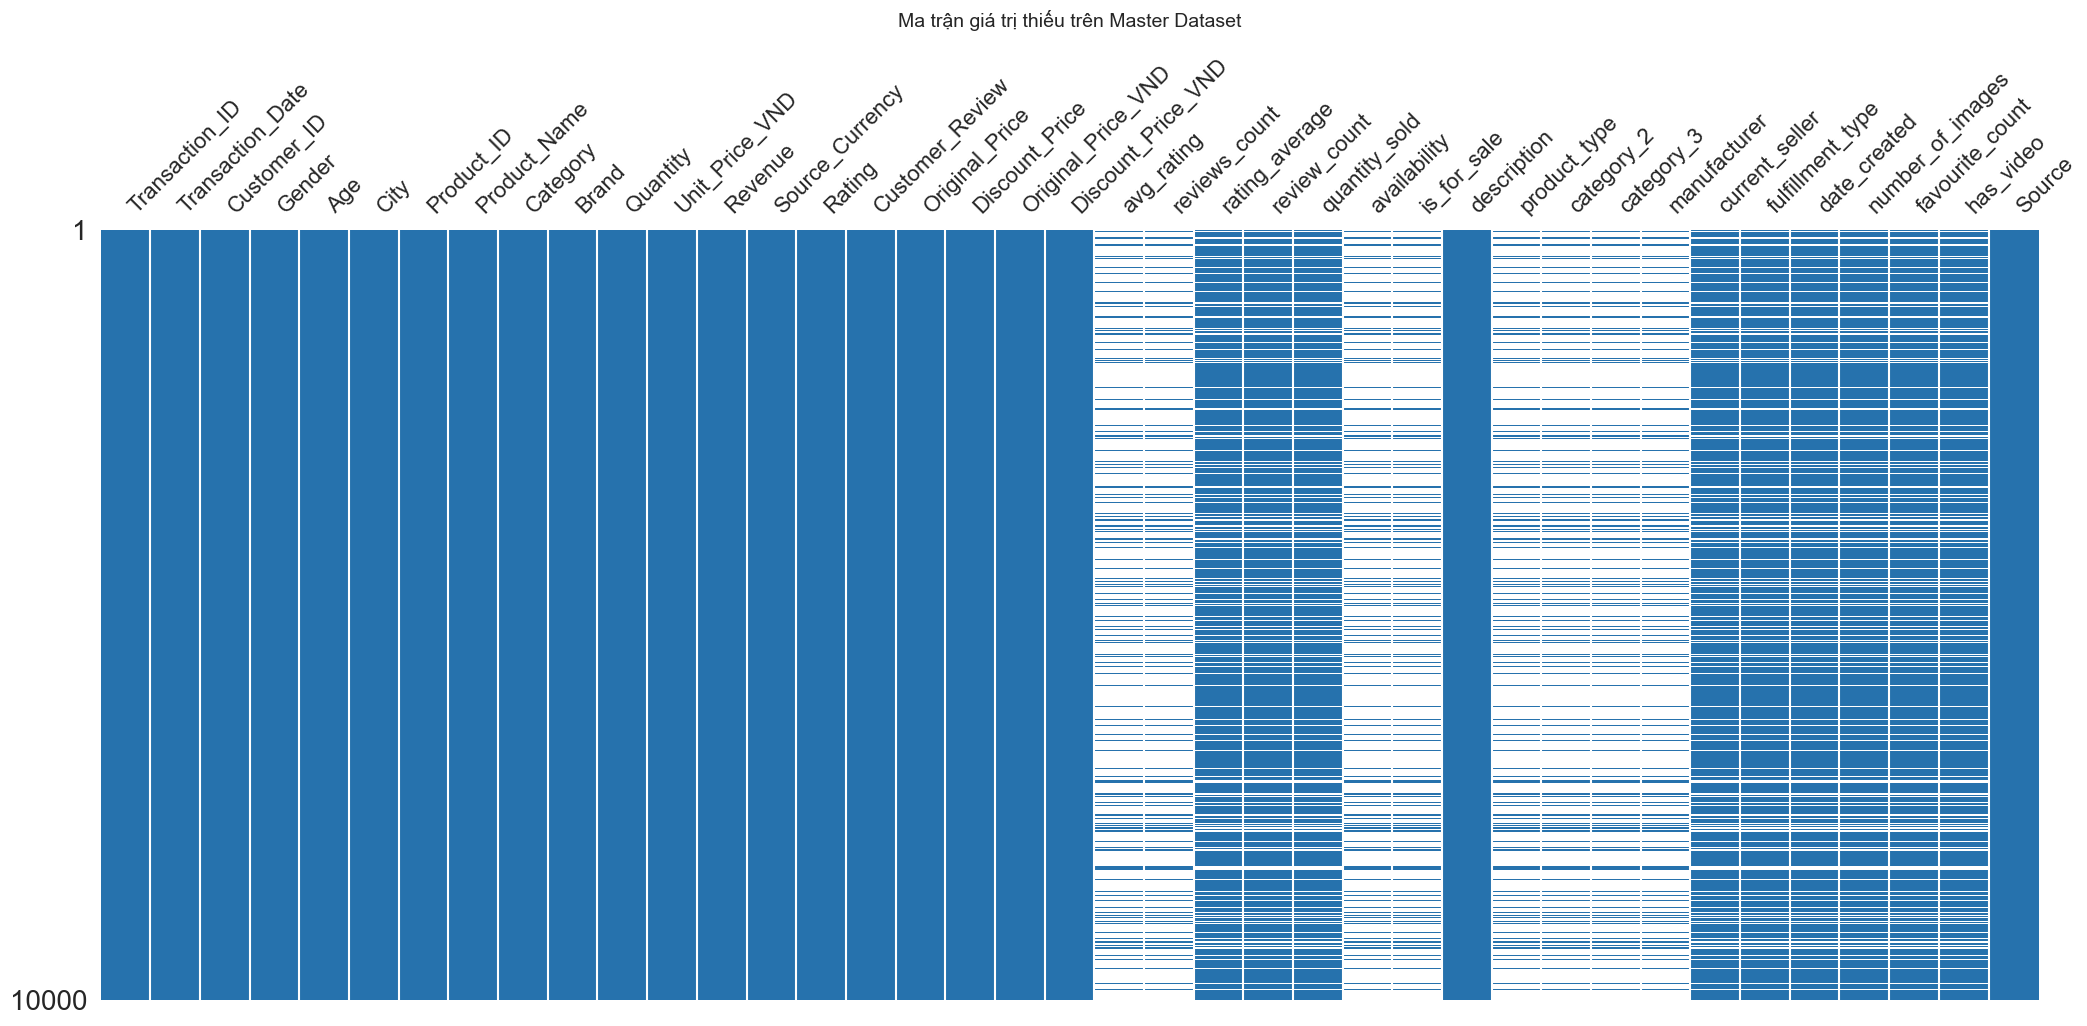

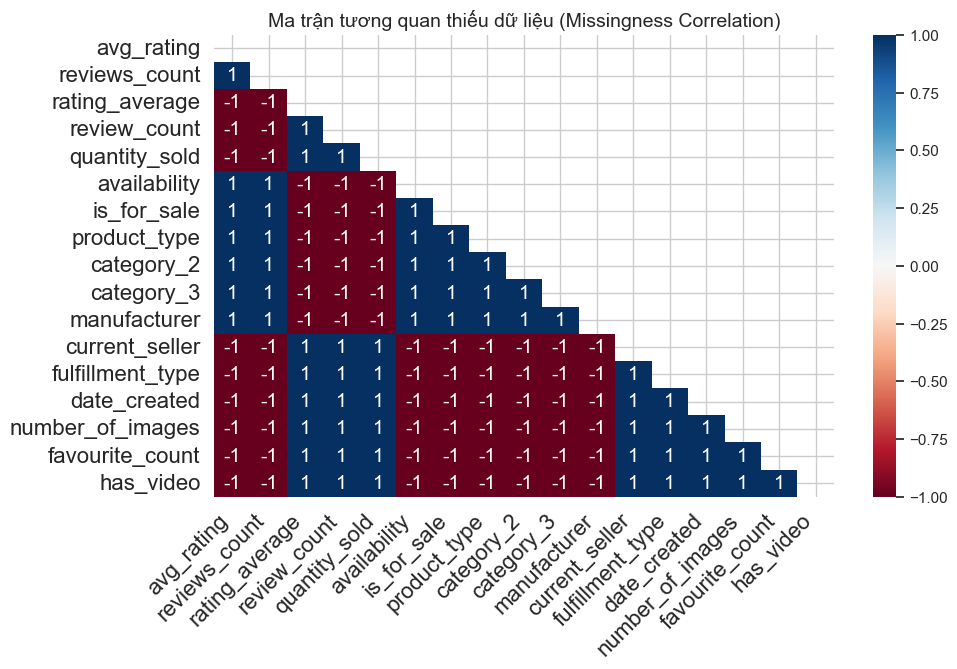

In [105]:
# Trực quan hóa Missing Values
plt.figure(figsize=(12, 6))
msno.matrix(df, sparkline=False, color=(0.15, 0.45, 0.68))
plt.title('Ma trận giá trị thiếu trên Master Dataset', fontsize=14, pad=20)
plt.show()

# Trực quan ma trận tương quan khuyết dữ liệu
msno.heatmap(df, figsize=(10, 6))
plt.title('Ma trận tương quan thiếu dữ liệu (Missingness Correlation)', fontsize=14)
plt.show()

Phân tích cơ chế thiếu dữ liệu (MCAR / MAR / MNAR).

Dựa trên kết quả phân tích hệ thống, cơ chế khuyết dữ liệu của tập hợp dữ liệu này thuộc dạng MAR (Missing At Random) do bản chất tích hợp hai nguồn dữ liệu không đồng nhất (Structural Missingness):

Tập cột thiếu 8.178 dòng (81,78%): Gồm avg_rating, reviews_count, availability, is_for_sale, product_type, category_2, category_3, manufacturer.

Lý do: Các thuộc tính này thuộc về nền tảng Tesco UK. Do đó, toàn bộ 8.178 giao dịch xuất phát từ dữ liệu Tiki VN hoàn toàn không có các thuộc tính này.

Tập cột thiếu 1.822 dòng (18,22%): Gồm rating_average, review_count, quantity_sold, current_seller, fulfillment_type, date_created, number_of_images, favourite_count, has_video.

Lý do: Các thuộc tính này thuộc về cấu trúc Schema của sàn Tiki VN. Do đó, 1.822 giao dịch xuất phát từ Tesco UK bị khuyết hoàn toàn các trường thông tin này.

Quyết định không dùng dropna(): Vì tỷ lệ khuyết dòng là 100% khi xét trên từng nguồn riêng biệt, nếu dùng dropna() sẽ xóa sạch toàn bộ 10.000 dòng dữ liệu. Do đó, phương pháp điền thế thích hợp (Imputation) là bắt buộc.

Lựa chọn phương pháp xử lý Imputation phù hợp (Mean, Median, Mode, Unknown). Giải thích rõ lý do nếu dùng dropna().

In [106]:
# Sao chép dataframe trước khi điền
df_cleaned = df.copy()

# 1. Đối với các cột định tính (Categorical): Điền 'Unknown' để thể hiện thuộc tính không tồn tại trên sàn đó
cat_missing_cols = [
    'availability', 'is_for_sale', 'product_type', 'category_2', 'category_3', 
    'manufacturer', 'current_seller', 'fulfillment_type', 'has_video', 'avg_rating', 'reviews_count'
]
for col in cat_missing_cols:
    df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# 2. Đối với các cột định lượng (Numerical): Điền 0 đại diện cho việc chưa có tương tác/chỉ số trên nền tảng còn lại
num_missing_cols = [
    'rating_average', 'review_count', 'quantity_sold', 
    'date_created', 'number_of_images', 'favourite_count'
]
for col in num_missing_cols:
    df_cleaned[col] = df_cleaned[col].fillna(0)

print(f"Tổng số giá trị khuyết sau Imputation: {df_cleaned.isna().sum().sum()}")

Tổng số giá trị khuyết sau Imputation: 0


So sánh phân phối dữ liệu Before / After Imputation

In [107]:
import IPython.display as display
import pandas as pd

cat_missing_cols = [
    'availability',
    'is_for_sale',
    'product_type',
    'category_2',
    'category_3',
    'manufacturer',
    'current_seller',
    'fulfillment_type',
    'has_video',
    'avg_rating',
    'reviews_count',
]

num_missing_cols = [
    'rating_average',
    'review_count',
    'quantity_sold',
    'date_created',
    'number_of_images',
    'favourite_count',
]

#SO SÁNH CỘT ĐỊNH LƯỢNG 

print('=' * 90)
print('SO SÁNH CÁC CỘT ĐỊNH LƯỢNG')
print('=' * 90)

df_num_before = df[num_missing_cols].apply(pd.to_numeric, errors='coerce')
df_num_after = df_cleaned[num_missing_cols].apply(
    pd.to_numeric, errors='coerce'
)

print('\n---> TRƯỚC')
display.display(df_num_before.describe().round(2).T)

print('\n---> SAU')
display.display(df_num_after.describe().round(2).T)



#SO SÁNH CỘT ĐỊNH TÍNH

print('\n' + '=' * 90)
print('SO SÁNH CÁC CỘT ĐỊNH TÍNH')
print('=' * 90)

for col in cat_missing_cols:
    if col in df.columns:
        # Chuẩn hóa chuỗi và đánh dấu rõ ô Missing trước khi đếm
        s_before = df[col].fillna('<Missing / NaN>').astype(str)
        s_after = df_cleaned[col].astype(str)

        # Tạo 2 bảng tần suất độc lập
        df_before_stats = pd.DataFrame({
            'Count (Before)': s_before.value_counts(),
            '% (Before)': (s_before.value_counts(normalize=True) * 100).round(2),
        })

        df_after_stats = pd.DataFrame({
            'Count (After)': s_after.value_counts(),
            '% (After)': (s_after.value_counts(normalize=True) * 100).round(2),
        })

        # Ghép 2 bảng bằng pd.concat theo cột (axis=1) để tránh hoàn toàn lỗi Index
        df_vc_compare = pd.concat(
            [df_before_stats, df_after_stats], axis=1
        ).fillna(0)

        # Sắp xếp danh mục theo số lượng ở tập After giảm dần
        df_vc_compare = df_vc_compare.sort_values(
            by='Count (After)', ascending=False
        )

        print(f"\n--->Cột: '{col}'")
        display.display(df_vc_compare.head(10))

SO SÁNH CÁC CỘT ĐỊNH LƯỢNG

---> TRƯỚC


,count,mean,std,min,25%,50%,75%,max
rating_average,8178.0,1.49,2.15,0.0,0.0,0.0,4.2,5.0
review_count,8178.0,4.29,21.93,0.0,0.0,0.0,1.0,525.0
quantity_sold,8178.0,22.81,108.88,0.0,0.0,1.0,6.0,2742.0
date_created,8178.0,1376.16,23058.99,0.0,321.0,550.0,839.0,738076.0
number_of_images,8178.0,6.13,3.56,1.0,3.0,6.0,9.0,41.0
favourite_count,8178.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0



---> SAU


,count,mean,std,min,25%,50%,75%,max
rating_average,10000.0,1.22,2.02,0.0,0.0,0.0,3.4,5.0
review_count,10000.0,3.51,19.90,0.0,0.0,0.0,1.0,525.0
quantity_sold,10000.0,18.65,98.85,0.0,0.0,0.0,4.0,2742.0
date_created,10000.0,1125.42,20859.31,0.0,93.0,448.0,755.0,738076.0
number_of_images,10000.0,5.02,4.00,0.0,1.0,5.0,8.0,41.0
favourite_count,10000.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0



SO SÁNH CÁC CỘT ĐỊNH TÍNH

--->Cột: 'availability'


...

,Count (Before),% (Before),Count (After),% (After)
has_video,,,,
False,7284.0,72.84,7284.0,72.84
Unknown,0.0,0.00,1822.0,18.22
True,894.0,8.94,894.0,8.94
<Missing / NaN>,1822.0,18.22,0.0,0.00



--->Cột: 'avg_rating'


,Count (Before),% (Before),Count (After),% (After)
avg_rating,,,,
Unknown,0.0,0.00,8178.0,81.78
\N,1822.0,18.22,1822.0,18.22
<Missing / NaN>,8178.0,81.78,0.0,0.00



--->Cột: 'reviews_count'


,Count (Before),% (Before),Count (After),% (After)
reviews_count,,,,
Unknown,0.0,0.00,8178.0,81.78
\N,1822.0,18.22,1822.0,18.22
<Missing / NaN>,8178.0,81.78,0.0,0.00


Đang vẽ biểu đồ cho 6 cột định lượng...


C:\Users\TUAN\AppData\Local\Temp\ipykernel_20280\4265207976.py:23: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\TUAN\AppData\Local\Temp\ipykernel_20280\4265207976.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\TUAN\AppData\Local\Temp\ipykernel_20280\4265207976.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


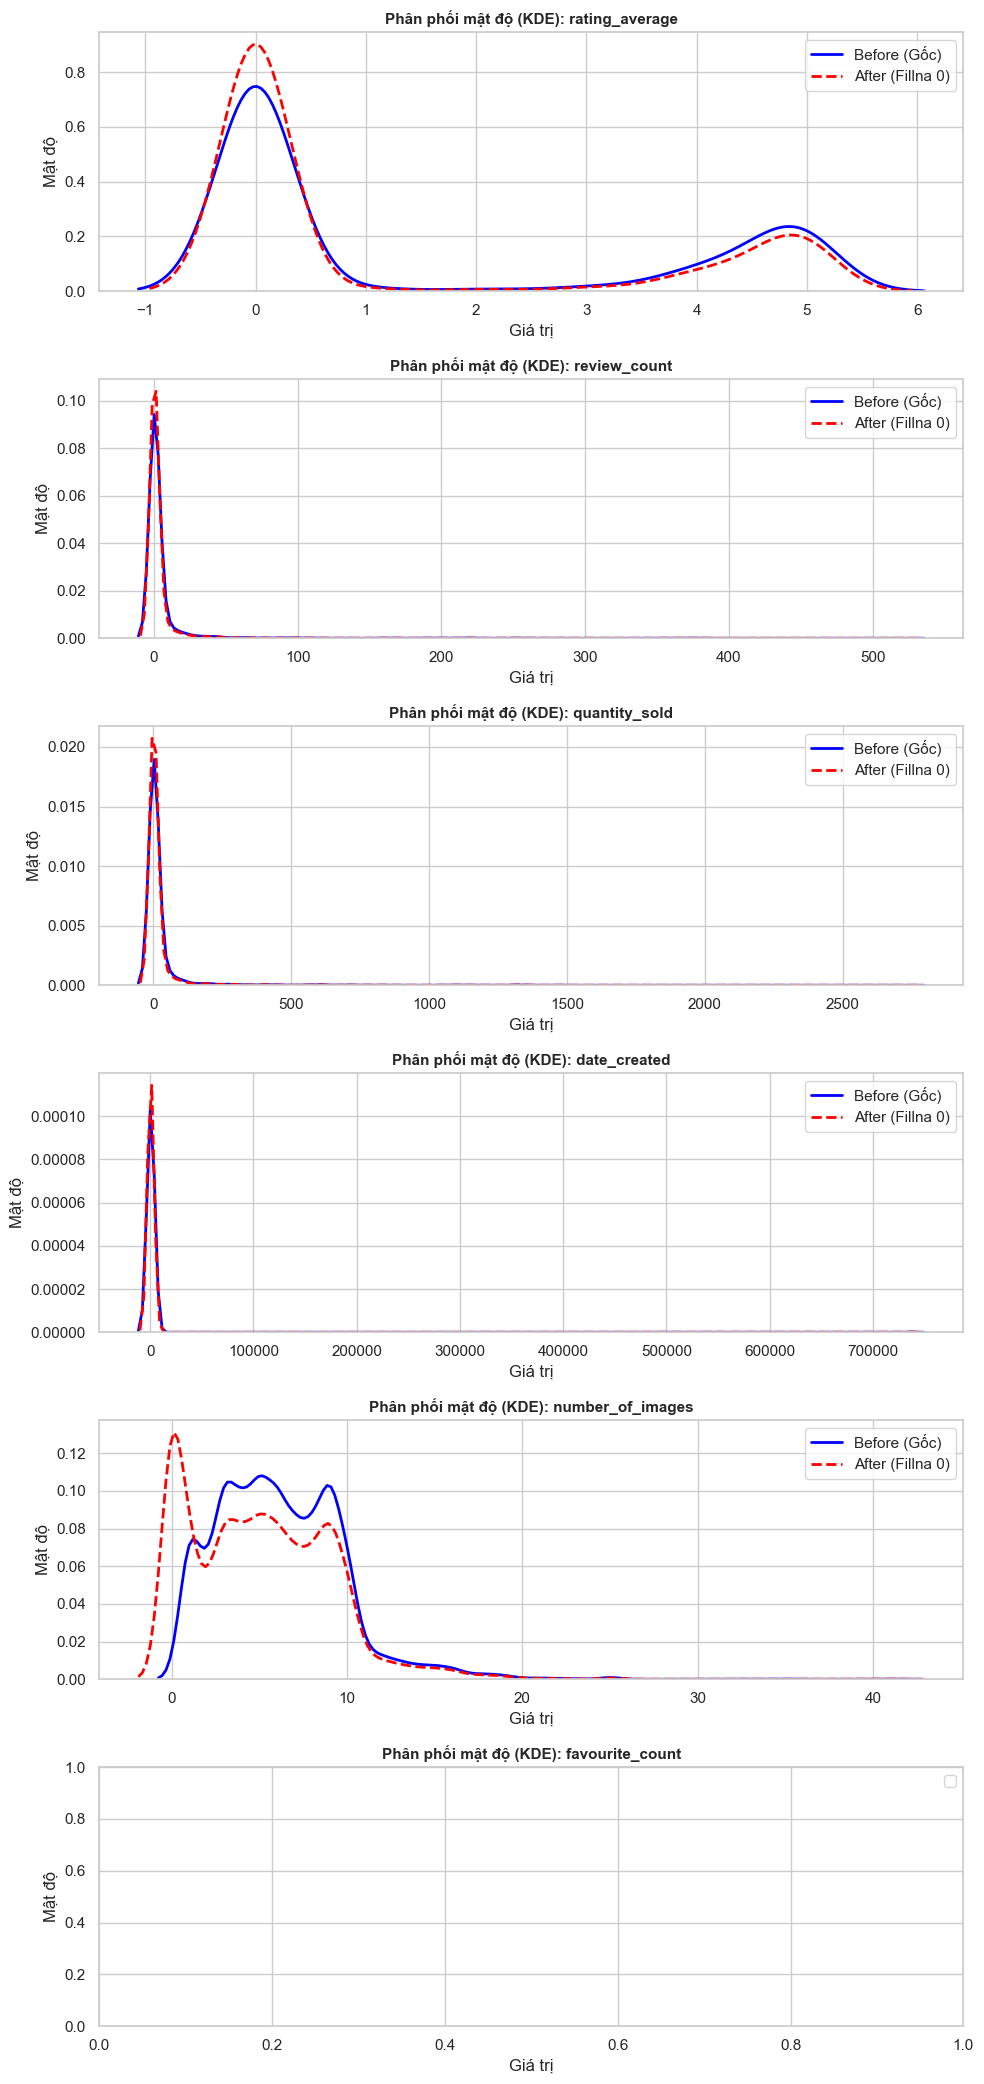

Đang vẽ biểu đồ cho 11 cột định tính...


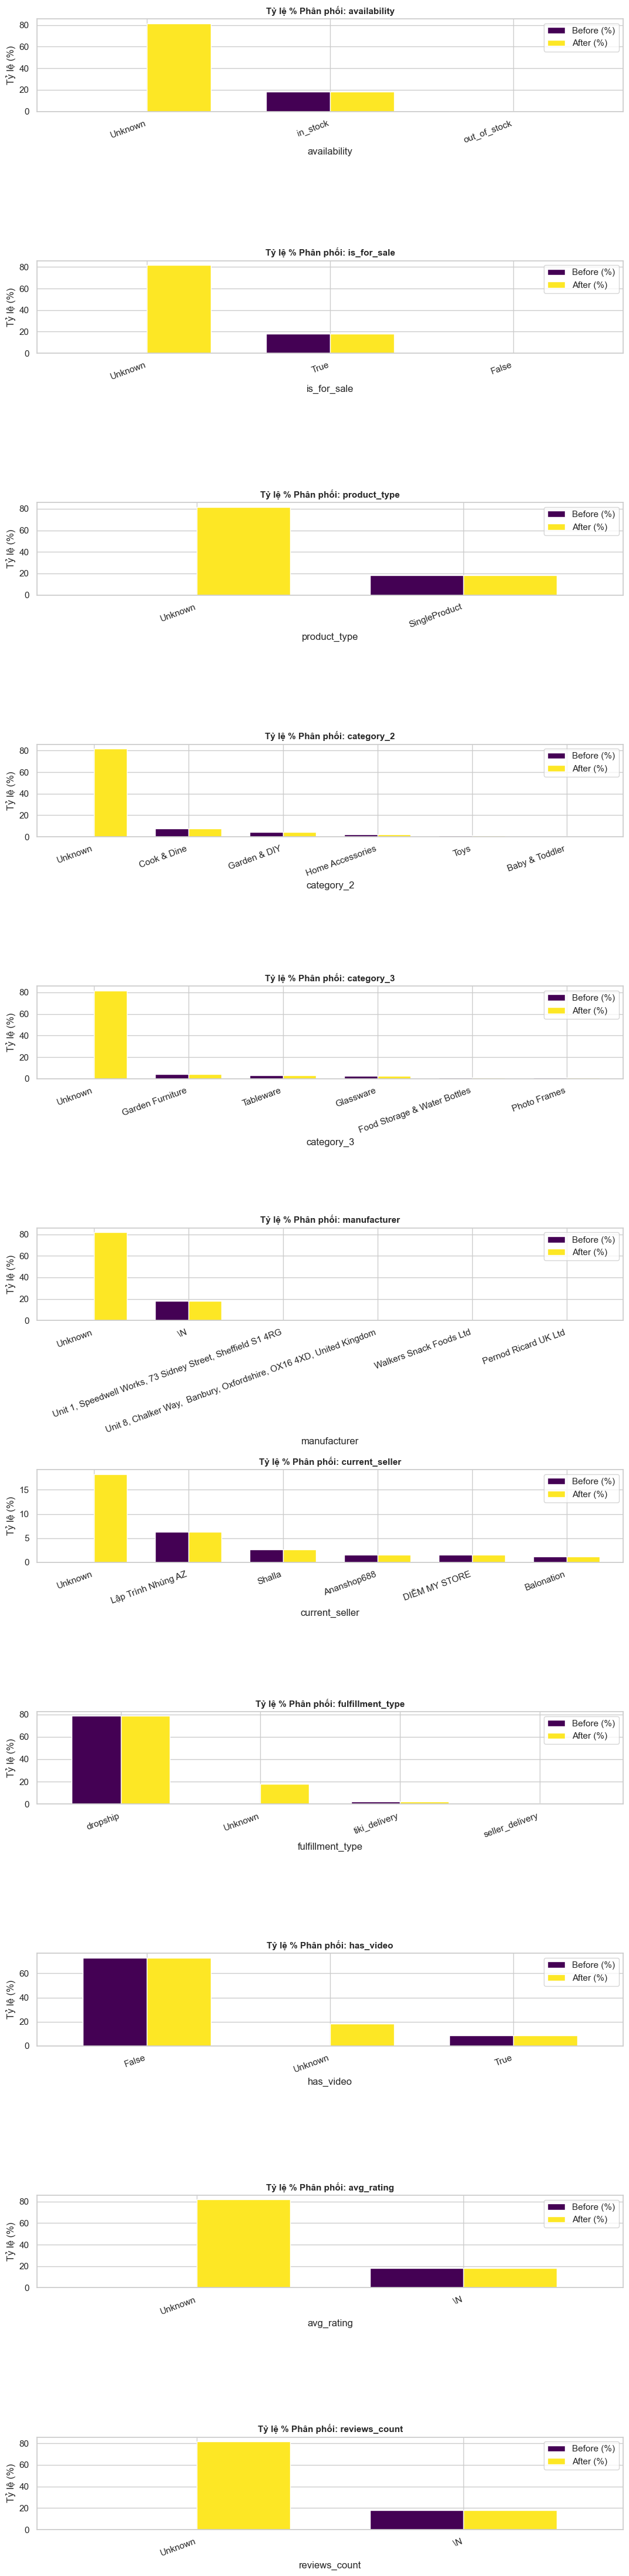

In [108]:
# ==============================================================================
# BIỂU ĐỒ SO SÁNH PHÂN PHỐI BEFORE / AFTER (ĐỦ 100% 17 CỘT)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

# ------------------------------------------------------------------------------
# 1. BIỂU ĐỒ CHO TẤT CẢ 6 CỘT ĐỊNH LƯỢNG (NUMERICAL)
# ------------------------------------------------------------------------------
print('Đang vẽ biểu đồ cho 6 cột định lượng...')
fig, axes = plt.subplots(
    len(num_missing_cols), 1, figsize=(10, 3.5 * len(num_missing_cols))
)

for i, col in enumerate(num_missing_cols):
    if col in df.columns:
        s_before = pd.to_numeric(df[col], errors='coerce').dropna()
        s_after = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0)

        sns.kdeplot(
            s_before,
            ax=axes[i],
            label='Before (Gốc)',
            color='blue',
            linewidth=2,
        )
        sns.kdeplot(
            s_after,
            ax=axes[i],
            label='After (Fillna 0)',
            color='red',
            linestyle='--',
            linewidth=2,
        )

        axes[i].set_title(
            f'Phân phối mật độ (KDE): {col}', fontsize=11, fontweight='bold'
        )
        axes[i].set_xlabel('Giá trị')
        axes[i].set_ylabel('Mật độ')
        axes[i].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 2. BIỂU ĐỒ CHO TẤT CẢ 11 CỘT ĐỊNH TÍNH (CATEGORICAL)
# ------------------------------------------------------------------------------
print('Đang vẽ biểu đồ cho 11 cột định tính...')
fig, axes = plt.subplots(
    len(cat_missing_cols), 1, figsize=(11, 4 * len(cat_missing_cols))
)

for i, col in enumerate(cat_missing_cols):
    if col in df.columns:
        # Lấy top 6 giá trị xuất hiện nhiều nhất ở tập After để vẽ
        top_cats = df_cleaned[col].astype(str).value_counts().head(6).index

        df_plot_before = (
            df[col]
            .fillna('<Missing>')
            .astype(str)
            .value_counts(normalize=True)
            .reindex(top_cats, fill_value=0)
            * 100
        )
        df_plot_after = (
            df_cleaned[col]
            .astype(str)
            .value_counts(normalize=True)
            .reindex(top_cats, fill_value=0)
            * 100
        )

        plot_data = pd.DataFrame(
            {'Before (%)': df_plot_before, 'After (%)': df_plot_after}
        )

        plot_data.plot(kind='bar', ax=axes[i], colormap='viridis', width=0.7)
        axes[i].set_title(
            f'Tỷ lệ % Phân phối: {col}', fontsize=11, fontweight='bold'
        )
        axes[i].set_ylabel('Tỷ lệ (%)')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=20, ha='right')
        axes[i].legend()

plt.tight_layout()
plt.show()

Phát hiện Outliers bằng IQR / Z-score và xử lý (Drop/Clip) tùy đặc điểm biến.

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display  

# 1. Xác định các cột số cần kiểm tra Outlier
numeric_cols = [
    'Age', 'Quantity', 'Unit_Price_VND', 'Revenue', 
    'Original_Price_VND', 'Discount_Price_VND', 
    'rating_average', 'review_count', 'quantity_sold', 
    'number_of_images', 'favourite_count'
]

# Chỉ chọn những cột thực sự có trong DataFrame
valid_num_cols = [col for col in numeric_cols if col in df.columns]

def detect_outliers_summary(data, columns):
    summary_list = []
    
    for col in columns:
        series = data[col].dropna()
        if len(series) == 0:
            continue
            
        # --- IQR Method ---
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_iqr = q1 - 1.5 * iqr
        upper_iqr = q3 + 1.5 * iqr
        outliers_iqr = series[(series < lower_iqr) | (series > upper_iqr)]
        
        # --- Z-Score Method ---
        mean_val = series.mean()
        std_val = series.std()
        if std_val > 0:
            z_scores = (series - mean_val) / std_val
            outliers_z = series[np.abs(z_scores) > 3]
        else:
            outliers_z = pd.Series([], dtype=float)
            
        summary_list.append({
            'Column': col,
            'Total_Non_Null': len(series),
            'Skewness': round(series.skew(), 2),
            'IQR_Lower': round(lower_iqr, 2),
            'IQR_Upper': round(upper_iqr, 2),
            'Outliers_IQR_Count': len(outliers_iqr),
            'Outliers_IQR_%': round(len(outliers_iqr) / len(series) * 100, 2),
            'Outliers_ZScore_Count': len(outliers_z),
            'Outliers_ZScore_%': round(len(outliers_z) / len(series) * 100, 2)
        })
        
    return pd.DataFrame(summary_list)

outlier_df = detect_outliers_summary(df, valid_num_cols)
print("THỐNG KÊ CHI TIẾT OUTLIERS TRÊN CÁC BIẾN SỐ:")
display(outlier_df)

THỐNG KÊ CHI TIẾT OUTLIERS TRÊN CÁC BIẾN SỐ:


,Column,Total_Non_Null,Skewness,IQR_Lower,IQR_Upper,Outliers_IQR_Count,Outliers_IQR_%,Outliers_ZScore_Count,Outliers_ZScore_%
0,Age,10000,0.03,-7.00,89.00,0,0.00,0,0.00
1,Quantity,10000,-0.01,-1.00,7.00,0,0.00,0,0.00
2,Unit_Price_VND,10000,7.18,-793500.00,1482500.00,1088,10.88,191,1.91
3,Revenue,10000,8.43,-2435001.25,4485000.75,1053,10.53,159,1.59
4,Original_Price_VND,10000,6.84,-879718.00,1639530.00,1072,10.72,185,1.85
5,Discount_Price_VND,10000,7.18,-793500.00,1482500.00,1088,10.88,191,1.91
6,rating_average,8178,0.81,-6.30,10.50,0,0.00,0,0.00
7,review_count,8178,11.88,-1.50,2.50,1491,18.23,86,1.05
8,quantity_sold,8178,11.07,-9.00,15.00,1341,16.40,109,1.33
9,number_of_images,8178,1.03,-6.00,18.00,47,0.57,94,1.15


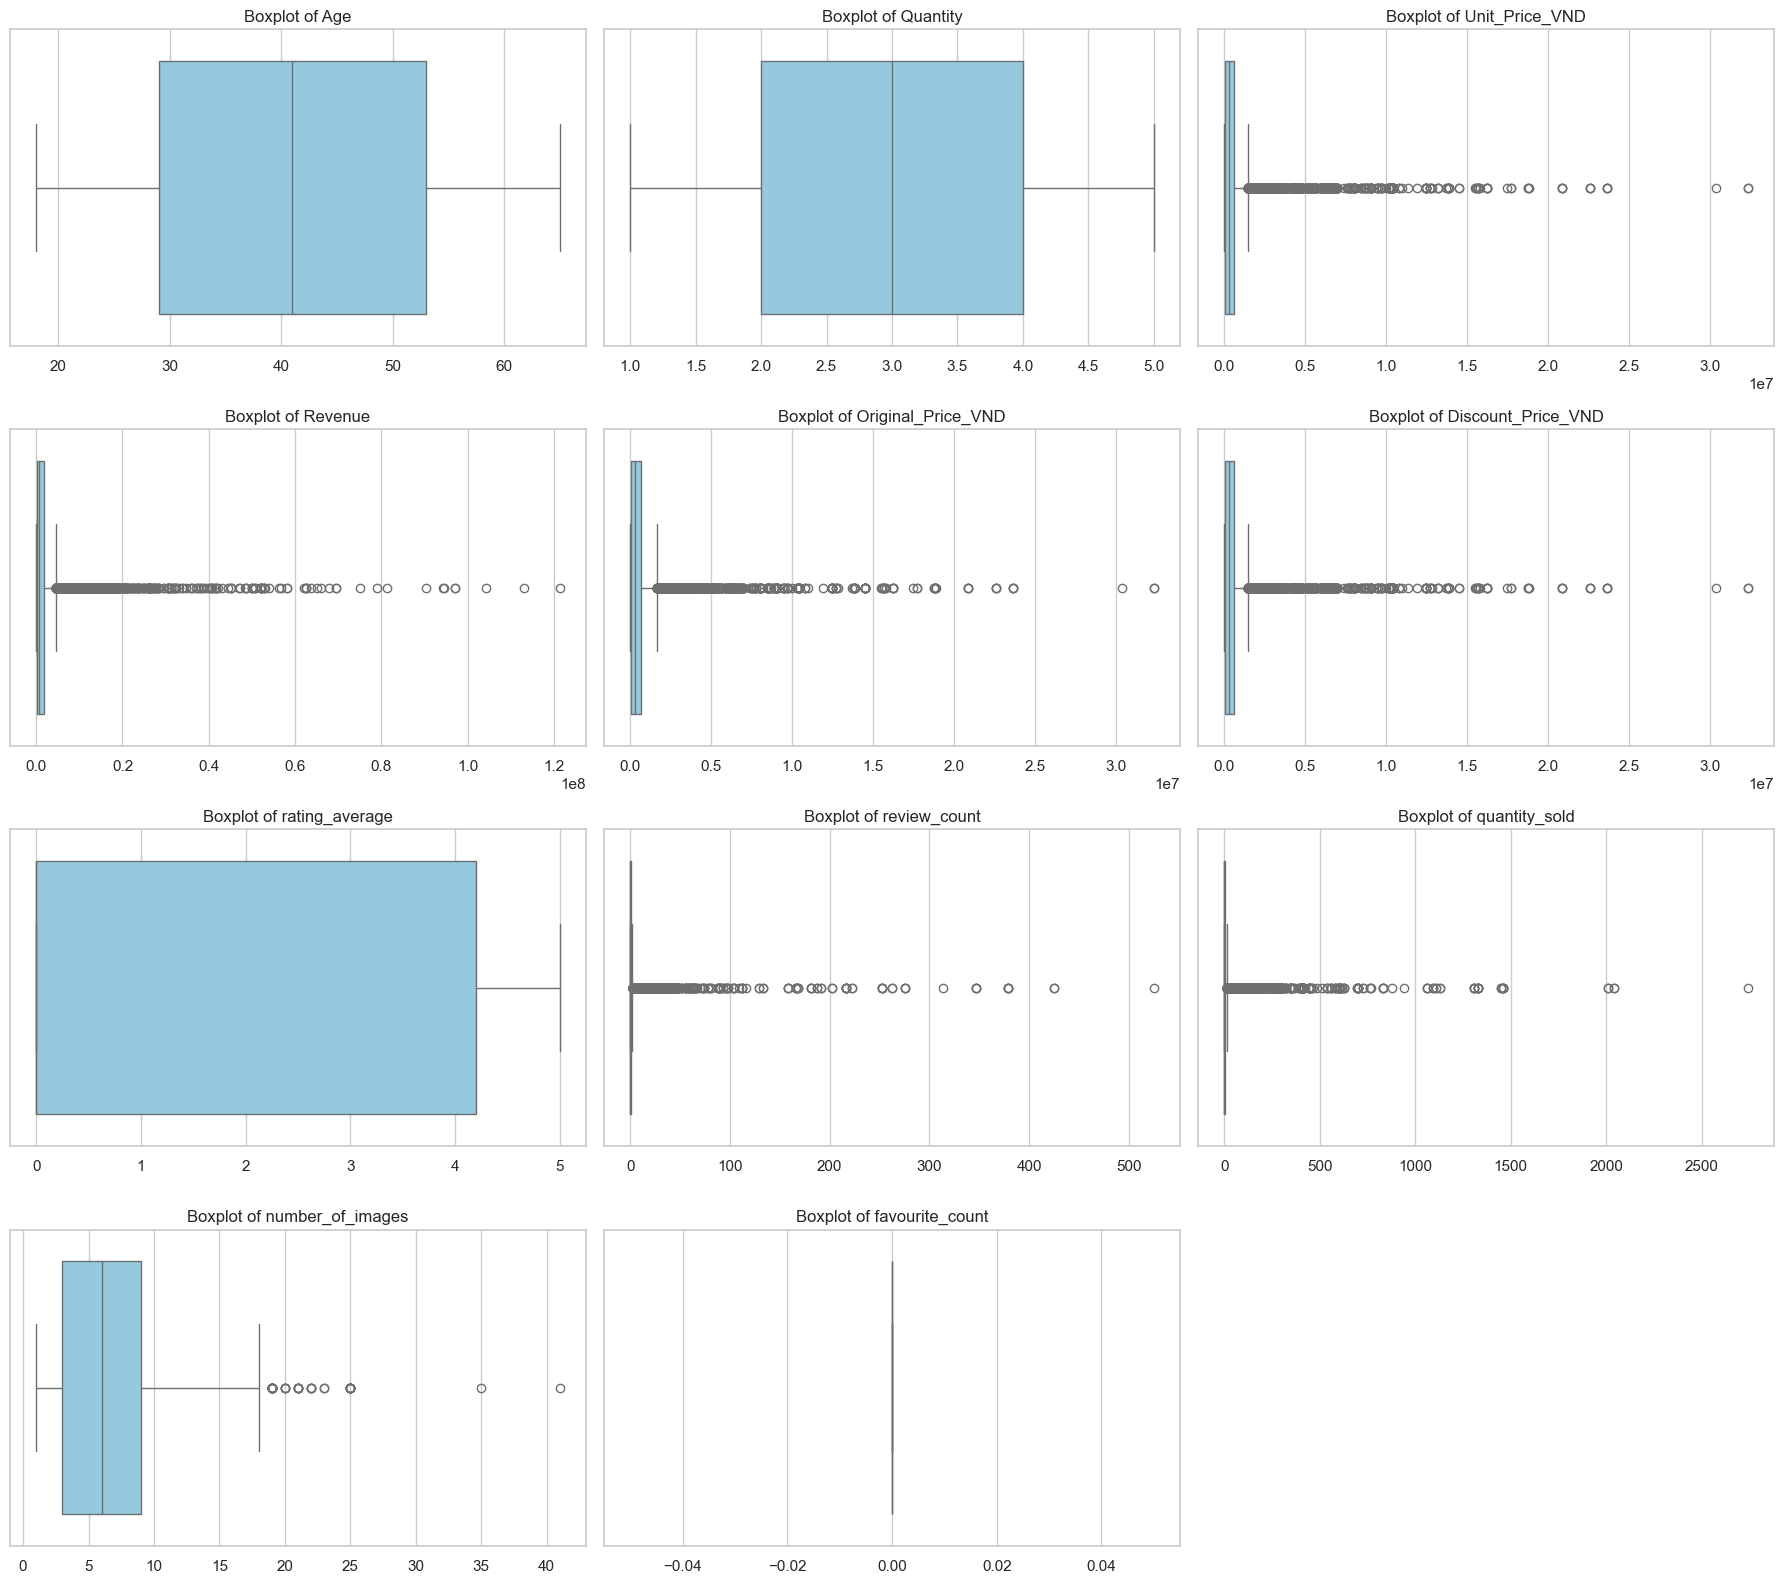

In [110]:
# Trực quan hóa các biến có nguy cơ có Outliers bằng Boxplot
fig, axes = plt.subplots(nrows=int(np.ceil(len(valid_num_cols)/3)), ncols=3, figsize=(18, 4 * np.ceil(len(valid_num_cols)/3)))
axes = axes.flatten()

for idx, col in enumerate(valid_num_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}', fontsize=12)
    axes[idx].set_xlabel('')

# Ẩn các subplot dư thừa
for idx in range(len(valid_num_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [111]:
# Tạo bản sao DataFrame để xử lý dữ liệu sạch
df_cleaned = df.copy()

print("BẮT ĐẦU XỬ LÝ OUTLIERS:\n")

# 1. Drop các giá trị bất hợp lý / rác (Logical Outliers) nếu có
# Ví dụ: Độ tuổi hợp lệ từ 10 đến 100
initial_len = len(df_cleaned)
if 'Age' in df_cleaned.columns:
    df_cleaned = df_cleaned[(df_cleaned['Age'] >= 10) & (df_cleaned['Age'] <= 100)]
    print(f"- Loại bỏ {initial_len - len(df_cleaned)} dòng do lỗi logic về Tuổi (Age < 10 hoặc Age > 100).")

# 2. Clipping (Capping) bằng IQR cho các biến có phân phối lệch mạnh nhưng cần giữ mẫu
# Các biến cần Clip: Quantity, review_count, favourite_count, quantity_sold, number_of_images
clip_cols_iqr = ['Quantity', 'review_count', 'favourite_count', 'quantity_sold', 'number_of_images']

for col in clip_cols_iqr:
    if col in df_cleaned.columns:
        q1 = df_cleaned[col].quantile(0.25)
        q3 = df_cleaned[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Đảm bảo ngưỡng dưới không âm đối với các thuộc tính số lượng/đếm
        lower_bound = max(0, lower_bound)
        
        # Capping dữ liệu vượt ngưỡng
        df_cleaned[col] = np.clip(df_cleaned[col], lower_bound, upper_bound)
        print(f"- Đã Capping (Clip) cột '{col}' trong khoảng [{lower_bound:.2f}, {upper_bound:.2f}].")

# 3. Clipping bằng Z-Score cho các biến có phân phối gần như chuẩn
# Ví dụ: rating_average
if 'rating_average' in df_cleaned.columns:
    mean_val = df_cleaned['rating_average'].mean()
    std_val = df_cleaned['rating_average'].std()
    
    # Giới hạn trong khoảng [-3 std, +3 std] và không vượt quá thang điểm 1-5
    lower_bound = max(1.0, mean_val - 3 * std_val)
    upper_bound = min(5.0, mean_val + 3 * std_val)
    
    df_cleaned['rating_average'] = np.clip(df_cleaned['rating_average'], lower_bound, upper_bound)
    print(f"- Đã Capping (Clip Z-score) cột 'rating_average' trong khoảng [{lower_bound:.2f}, {upper_bound:.2f}].")

# 4. Giữ nguyên đối với các biến doanh thu/giá tiền (Revenue, Price, Discount) 
# vì mang bản chất biến động giá trị giao dịch thực tế của sàn TMĐT.
print("- Giữ nguyên các cột 'Revenue', 'Unit_Price_VND', 'Original_Price_VND', 'Discount_Price_VND' để phản ánh đúng thực tế kinh doanh.")

print("\nHoàn tất xử lý Outliers!")
print(f"Kích thước tập dữ liệu sau khi xử lý: {df_cleaned.shape}")

BẮT ĐẦU XỬ LÝ OUTLIERS:

- Loại bỏ 0 dòng do lỗi logic về Tuổi (Age < 10 hoặc Age > 100).
- Đã Capping (Clip) cột 'Quantity' trong khoảng [0.00, 7.00].
- Đã Capping (Clip) cột 'review_count' trong khoảng [0.00, 2.50].
- Đã Capping (Clip) cột 'favourite_count' trong khoảng [0.00, 0.00].
- Đã Capping (Clip) cột 'quantity_sold' trong khoảng [0.00, 15.00].
- Đã Capping (Clip) cột 'number_of_images' trong khoảng [0.00, 18.00].
- Đã Capping (Clip Z-score) cột 'rating_average' trong khoảng [1.00, 5.00].
- Giữ nguyên các cột 'Revenue', 'Unit_Price_VND', 'Original_Price_VND', 'Discount_Price_VND' để phản ánh đúng thực tế kinh doanh.

Hoàn tất xử lý Outliers!
Kích thước tập dữ liệu sau khi xử lý: (10000, 39)


In [112]:
# So sánh lại Skewness trước và sau khi xử lý
comparison_list = []
for col in valid_num_cols:
    comparison_list.append({
        'Column': col,
        'Original_Skewness': round(df[col].skew(), 2),
        'Cleaned_Skewness': round(df_cleaned[col].skew(), 2)
    })

comparison_df = pd.DataFrame(comparison_list)
print("SO SÁNH ĐỘ LỆCH (SKEWNESS) TRƯỚC VÀ SAU XỬ LÝ:")
display(comparison_df)

SO SÁNH ĐỘ LỆCH (SKEWNESS) TRƯỚC VÀ SAU XỬ LÝ:


,Column,Original_Skewness,Cleaned_Skewness
0,Age,0.03,0.03
1,Quantity,-0.01,-0.01
2,Unit_Price_VND,7.18,7.18
3,Revenue,8.43,8.43
4,Original_Price_VND,6.84,6.84
5,Discount_Price_VND,7.18,7.18
6,rating_average,0.81,0.85
7,review_count,11.88,1.07
8,quantity_sold,11.07,1.19
9,number_of_images,1.03,0.68
